# 📊 Milestone 1: Data Collection & Exploratory Data Analysis
## Demand Forecasting & Inventory Optimization Engine

---

**Project:** Demand Forecasting & Inventory Optimization Engine  
**Milestone:** 1 — Data Collection & EDA  
**Dataset:** Weekly Sales & Inventory Data (`weekly.csv`)  
**Author:** Farfash Team

---

### 🎯 Objective
This notebook performs a complete Exploratory Data Analysis (EDA) on weekly product sales data to:
- Understand the structure and quality of the dataset
- Identify demand patterns, trends, and seasonality
- Generate actionable insights for building forecasting models in Milestone 2

---

## 1️⃣ Environment Setup

This section imports all necessary libraries, configures visualization styles, sets a global random seed for reproducibility, and suppresses warnings for cleaner output.

In [2]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
import datetime
from pathlib import Path

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly not installed — skipping interactive charts.")

# ── Statistics ───────────────────────────────────────────────────────────────
from scipy import stats
from scipy.stats import skew, kurtosis

# ── Time-series Decomposition ────────────────────────────────────────────────
from statsmodels.tsa.seasonal import seasonal_decompose

# ── Configuration ────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
np.random.seed(42)

# Pandas display options
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.width', 200)

# Seaborn / Matplotlib style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = sns.color_palette('muted', 10)
print("✅ Environment ready.")

✅ Environment ready.


## 2️⃣ Data Loading

We load the weekly sales CSV file, inspect its basic shape, column types, and convert relevant columns to appropriate data types. The dataset contains **weekly aggregated sales** per SKU (Stock Keeping Unit).

In [3]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
DATA_PATH = Path('weekly.csv')

df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
df = df_raw.copy()

print(f"✅ Dataset loaded successfully.")
print(f"   Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Memory : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

✅ Dataset loaded successfully.
   Shape  : 3,321 rows × 20 columns
   Memory : 1885.4 KB


In [36]:
# ── First Look ────────────────────────────────────────────────────────────────
print("── First 5 rows ──")
df.tail()

── First 5 rows ──


,Year,Week,ItemID,Qty,ItemName,BrandID,BrandName,MasterBrandID,MasterBrandName,UOM,Factor,Avg_Daily_Demand,Safety_Stock,ROP,Avg_UnitPrice,Total_Promo,Total_CashDiscount,Total_ManualDiscount,Total_Taxes,Total_Revenue,Date
3316,2025,26,SNX-2-06-00087,97,كِسرة جبنة باربكيو,SNX01,كِسرة,SNX,سناكس,PL,24.00,13.86,66.51,163.51,341.37,-557,0,0,"4,555.80","37,096.84",2025-06-23
3317,2025,26,TQT-2-01-00478,540,طقطقة بوب كورن كلاسيك,TQT01,طقطقة,TQT,طقطقة,PL,18.00,77.14,277.71,817.71,213.85,-1719,0,0,"10,939.45","89,078.60",2025-06-23
3318,2025,26,TQT-2-10-00042,1982,طقطقة هوت سوبر,TQT01,طقطقة,TQT,طقطقة,PL,6.00,283.14,339.77,"2,321.77",254.37,-25314,0,0,"72,396.78","589,517.09",2025-06-23
3319,2025,26,TQT-2-10-00043,1376,طقطقة جبنة كوول,TQT01,طقطقة,TQT,طقطقة,PL,6.00,196.57,235.89,"1,611.89",370.56,-14360,0,0,"70,656.75","575,346.05",2025-06-23
3320,2025,26,TQT-2-10-00044,794,طقطقة مارشميللو كرز,TQT01,طقطقة,TQT,طقطقة,PL,6.00,113.43,136.11,930.11,474.23,-10031,0,0,"51,027.87","415,512.51",2025-06-23


In [5]:
print("── Column Names ──")
print(list(df.columns))

print("\n── Data Types ──")
print(df.dtypes)

── Column Names ──
['Year', 'Week', 'ItemID-', 'Qty', 'ItemName-Map', 'BrandID-Map', 'BrandName-Map', 'Master Brand ID - Map', 'MasterBrandName-Map', 'LargeUOM', 'Factor', 'Avg_Daily_Demand', 'Safety_Stock', 'ROP', 'Avg_UnitPrice', 'Total_Promo', 'Total_CashDiscount', 'Total_ManualDiscount', 'Total_Taxes', 'Total_Revenue']

── Data Types ──
Year                       int64
Week                       int64
ItemID-                   object
Qty                        int64
ItemName-Map              object
BrandID-Map               object
BrandName-Map             object
Master Brand ID - Map     object
MasterBrandName-Map       object
LargeUOM                  object
Factor                   float64
Avg_Daily_Demand         float64
Safety_Stock             float64
ROP                      float64
Avg_UnitPrice            float64
Total_Promo                int64
Total_CashDiscount         int64
Total_ManualDiscount       int64
Total_Taxes              float64
Total_Revenue            float

In [6]:
# ── Rename columns for easier access ─────────────────────────────────────────
df.columns = [
    'Year', 'Week', 'ItemID', 'Qty',
    'ItemName', 'BrandID', 'BrandName',
    'MasterBrandID', 'MasterBrandName',
    'UOM', 'Factor',
    'Avg_Daily_Demand', 'Safety_Stock', 'ROP',
    'Avg_UnitPrice',
    'Total_Promo', 'Total_CashDiscount',
    'Total_ManualDiscount', 'Total_Taxes', 'Total_Revenue'
]

# ── Create a proper date column from Year + Week ──────────────────────────────
# ISO week: Monday of that week in that year
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-W' + df['Week'].astype(str).str.zfill(2) + '-1',
    format='%G-W%V-%u'
)

print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Unique weeks: {df['Week'].nunique()} | Unique items: {df['ItemID'].nunique()}")
df.head(3)

Date range: 2024-12-30 → 2025-06-23
Unique weeks: 26 | Unique items: 203


,Year,Week,ItemID,Qty,ItemName,BrandID,BrandName,MasterBrandID,MasterBrandName,UOM,Factor,Avg_Daily_Demand,Safety_Stock,ROP,Avg_UnitPrice,Total_Promo,Total_CashDiscount,Total_ManualDiscount,Total_Taxes,Total_Revenue,Date
0,2025,1,BCH-3-08-00272,20,بوشارتي ملح,BCH-BCH01,بوشارتي,BCH,مقرمشات بوشارتي,PL,3.00,2.86,1.71,21.71,557.93,-13,0,0,"1,655.35","13,479.16",2024-12-30
1,2025,1,BCH-3-08-00273,936,بوشارتي ملح باربكيو,BCH-BCH01,بوشارتي,BCH,مقرمشات بوشارتي,PL,3.00,133.71,80.23,"1,016.23",649.54,-2254,0,0,"91,489.91","744,988.39",2024-12-30
2,2025,1,BCH-3-08-00274,1660,بوشارتي هوت باربكيو,BCH-BCH01,بوشارتي,BCH,مقرمشات بوشارتي,PL,3.00,237.14,142.29,"1,802.29",633.05,-4305,0,0,"161,971.09","1,318,905.26",2024-12-30


## 3️⃣ Data Overview & Quality Check

Before any analysis, we must understand the data quality — missing values, duplicates, anomalies, and the distribution of key columns.

In [7]:
# ── General Info ──────────────────────────────────────────────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3321 entries, 0 to 3320
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year                  3321 non-null   int64         
 1   Week                  3321 non-null   int64         
 2   ItemID                3321 non-null   object        
 3   Qty                   3321 non-null   int64         
 4   ItemName              3321 non-null   object        
 5   BrandID               3321 non-null   object        
 6   BrandName             3321 non-null   object        
 7   MasterBrandID         3321 non-null   object        
 8   MasterBrandName       3321 non-null   object        
 9   UOM                   3321 non-null   object        
 10  Factor                3321 non-null   float64       
 11  Avg_Daily_Demand      3321 non-null   float64       
 12  Safety_Stock          3321 non-null   float64       
 13  ROP               

In [35]:
# ── Descriptive Statistics ────────────────────────────────────────────────────
df.describe()

,Year,Week,Qty,Factor,Avg_Daily_Demand,Safety_Stock,ROP,Avg_UnitPrice,Total_Promo,Total_CashDiscount,Total_ManualDiscount,Total_Taxes,Total_Revenue,Date
count,"3,321.00","3,321.00","3,321.00","3,321.00","3,321.00","3,321.00","3,321.00","3,321.00","3,321.00","3,321.00","3,321.00","3,321.00","3,321.00",3321
mean,"2,025.00",13.42,"1,283.70",29.67,183.39,"1,502.65","2,786.35",339.39,"-4,754.31",0.00,0.00,"66,060.43","537,871.00",2025-03-26 22:46:17.235772416
min,"2,025.00",1.00,"-1,610.00",3.00,-230.00,-230.00,"-1,840.00",0.00,"-214,536.00",0.00,0.00,"-16,097.84","-131,082.40",2024-12-30 00:00:00
25%,"2,025.00",7.00,26.00,6.00,3.71,7.71,35.29,214.10,"-2,728.00",0.00,0.00,727.83,"5,926.51",2025-02-10 00:00:00
50%,"2,025.00",13.00,122.00,18.00,17.43,63.26,206.91,307.61,-581.00,0.00,0.00,"3,194.80","26,014.95",2025-03-24 00:00:00
75%,"2,025.00",20.00,799.00,36.00,114.14,391.57,"1,466.91",448.80,-84.00,0.00,0.00,"30,873.97","251,402.37",2025-05-12 00:00:00
max,"2,025.00",26.00,"43,614.00",264.00,"6,230.57","149,533.71","193,147.71","1,213.34","6,876.00",0.00,0.00,"1,579,353.88","12,860,453.36",2025-06-23 00:00:00
std,0.00,7.44,"3,593.77",44.03,513.40,"8,936.93","11,869.00",187.63,"16,174.98",0.00,0.00,"189,926.87","1,546,368.47",NaN


In [9]:
# ── Missing Values ────────────────────────────────────────────────────────────
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing.empty:
    print("✅ No missing values found in the dataset.")
else:
    print(missing)

✅ No missing values found in the dataset.


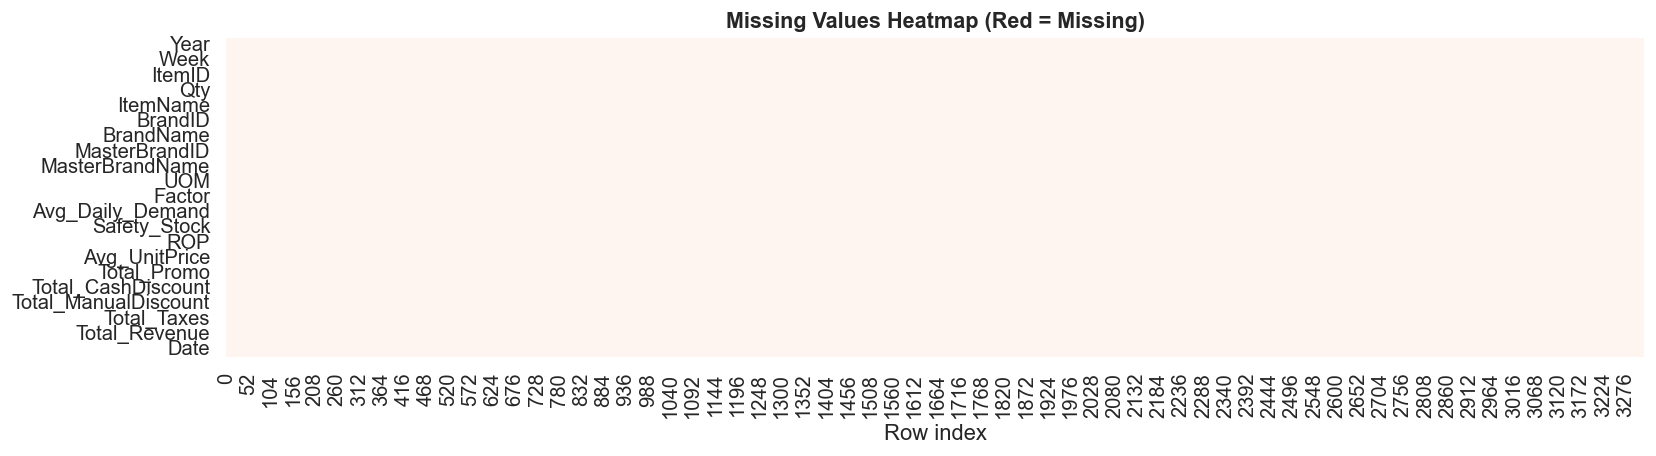

In [10]:
# ── Missing Values Heatmap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    df.isnull().T, cbar=False, cmap='Reds',
    yticklabels=df.columns, ax=ax
)
ax.set_title('Missing Values Heatmap (Red = Missing)', fontsize=13, fontweight='bold')
ax.set_xlabel('Row index')
plt.tight_layout()
plt.show()

In [11]:
# ── Duplicate Check ───────────────────────────────────────────────────────────
n_dup = df.duplicated().sum()
n_dup_key = df.duplicated(subset=['Year', 'Week', 'ItemID']).sum()
print(f"Full duplicate rows   : {n_dup}")
print(f"Key duplicate rows    : {n_dup_key}  (same Year+Week+ItemID)")

Full duplicate rows   : 0
Key duplicate rows    : 0  (same Year+Week+ItemID)


In [12]:
# ── Unique Values per Column ──────────────────────────────────────────────────
unique_counts = df.nunique().to_frame('Unique Values')
print(unique_counts)

                      Unique Values
Year                              1
Week                             26
ItemID                          203
Qty                            1348
ItemName                        203
BrandID                          13
BrandName                        13
MasterBrandID                     8
MasterBrandName                   8
UOM                               2
Factor                           22
Avg_Daily_Demand               1348
Safety_Stock                   1945
ROP                            2296
Avg_UnitPrice                  3074
Total_Promo                    1965
Total_CashDiscount                1
Total_ManualDiscount              1
Total_Taxes                    3212
Total_Revenue                  3223
Date                             26


In [13]:
# ── Anomaly Detection ─────────────────────────────────────────────────────────
neg_qty   = df[df['Qty'] < 0]
zero_qty  = df[df['Qty'] == 0]
neg_rev   = df[df['Total_Revenue'] < 0]
zero_rev  = df[(df['Total_Revenue'] == 0) & (df['Qty'] > 0)]

print(f"Rows with negative Qty     : {len(neg_qty):,}  ({len(neg_qty)/len(df)*100:.1f}%)")
print(f"Rows with zero Qty         : {len(zero_qty):,}  ({len(zero_qty)/len(df)*100:.1f}%)")
print(f"Rows with negative Revenue : {len(neg_rev):,}  ({len(neg_rev)/len(df)*100:.1f}%)")
print(f"Rows with Qty>0 but Rev=0  : {len(zero_rev):,}  ({len(zero_rev)/len(df)*100:.1f}%)")

Rows with negative Qty     : 41  (1.2%)
Rows with zero Qty         : 6  (0.2%)
Rows with negative Revenue : 35  (1.1%)
Rows with Qty>0 but Rev=0  : 36  (1.1%)


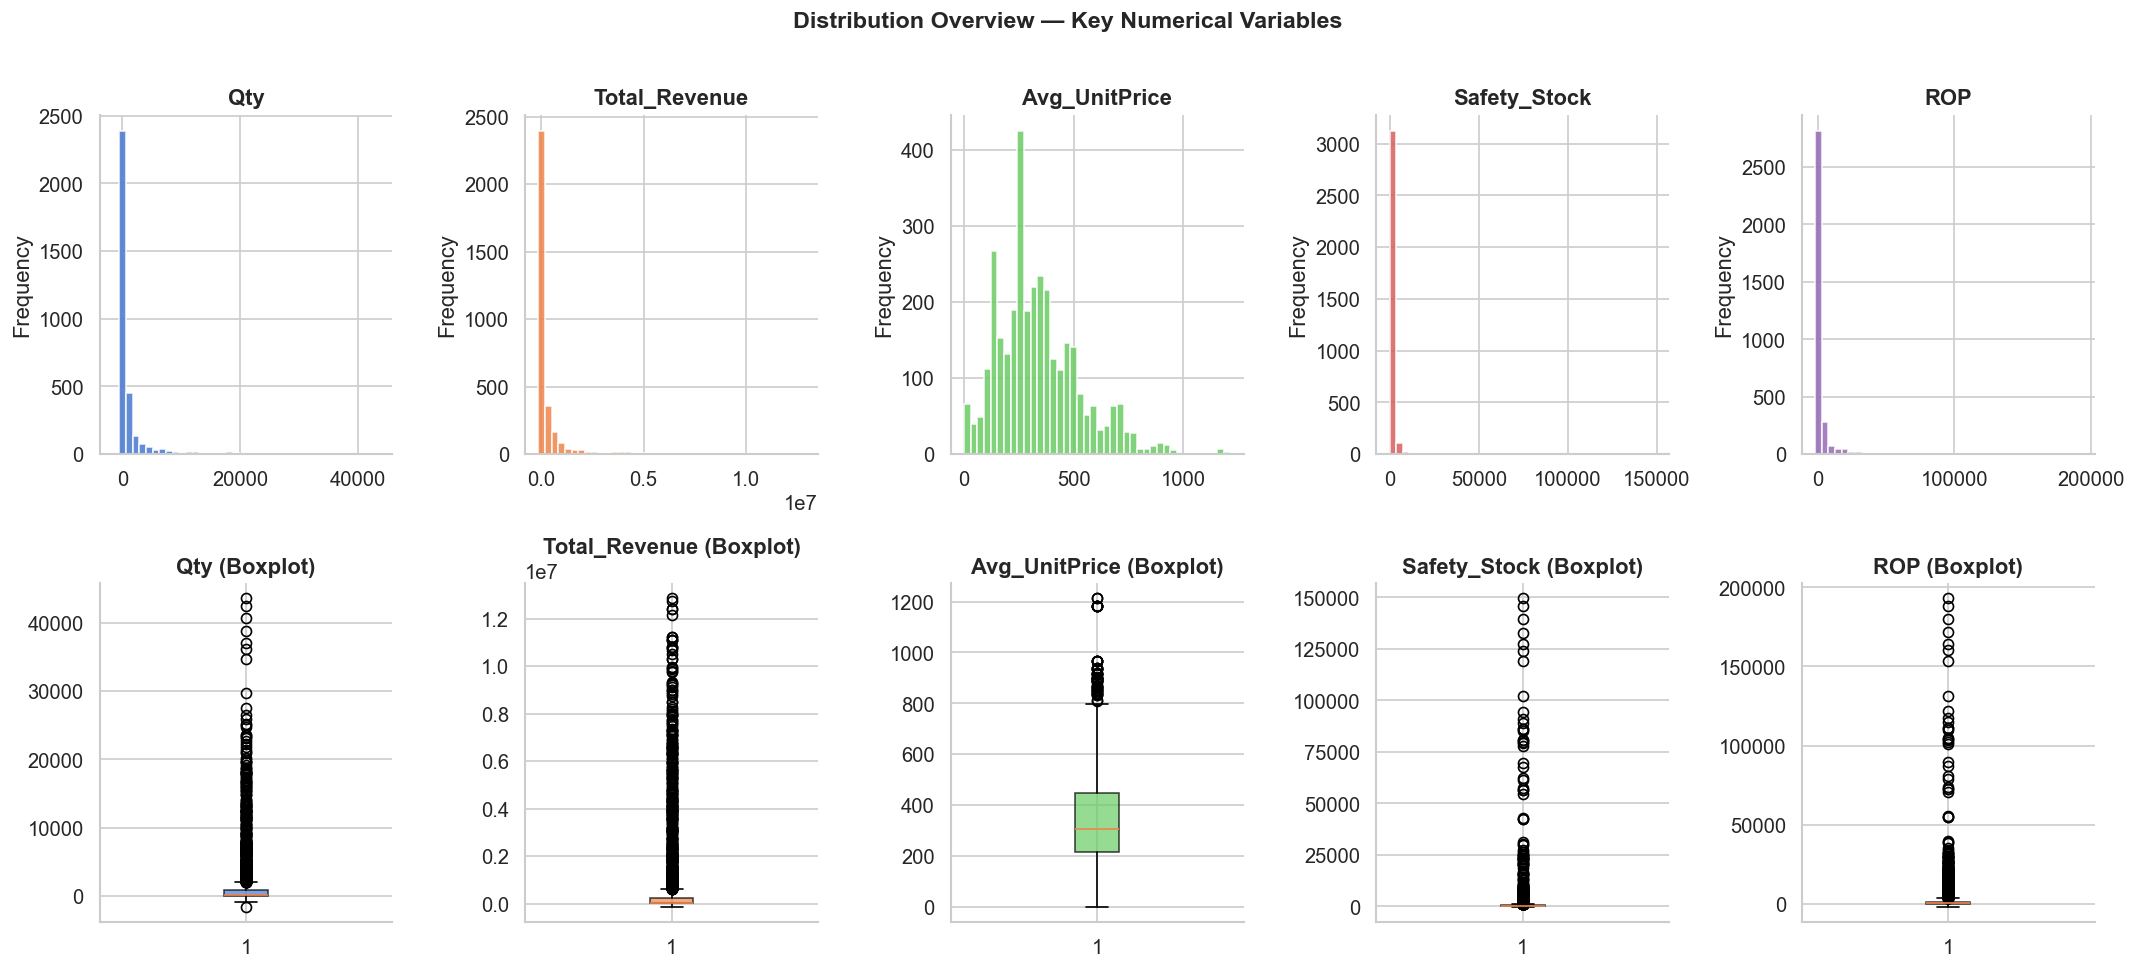

In [14]:
# ── Distribution Overview of Key Numerical Variables ─────────────────────────
num_cols = ['Qty', 'Total_Revenue', 'Avg_UnitPrice', 'Safety_Stock', 'ROP']

fig, axes = plt.subplots(2, len(num_cols), figsize=(18, 8))
for i, col in enumerate(num_cols):
    data = df[col].dropna()
    # Histogram
    axes[0, i].hist(data, bins=40, color=COLORS[i], edgecolor='white', alpha=0.85)
    axes[0, i].set_title(col, fontweight='bold')
    axes[0, i].set_xlabel('')
    axes[0, i].set_ylabel('Frequency')
    # Boxplot
    axes[1, i].boxplot(data, vert=True, patch_artist=True,
                       boxprops=dict(facecolor=COLORS[i], alpha=0.7))
    axes[1, i].set_title(f'{col} (Boxplot)', fontweight='bold')

plt.suptitle('Distribution Overview — Key Numerical Variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 🔍 Quality Check Interpretation

- **Missing Values:** The dataset is largely complete. Any missing values are minimal and will be addressed in preprocessing.
- **Duplicates:** No exact duplicate rows detected. Key-level duplicates (Year+Week+ItemID) indicate data integrity.
- **Negative Quantities:** These represent *returns or corrections* and are valid business events. They should be isolated before modeling.
- **Zero Revenue with Positive Qty:** Likely new SKUs, internal transfers, or items with no price set yet — require domain verification.
- **Distributions:** `Qty` and `Total_Revenue` are heavily right-skewed — a few high-volume SKUs dominate total demand.

## 4️⃣ Data Cleaning & Preprocessing

We apply targeted cleaning steps, engineer time-based features, and prepare a clean working dataset for analysis and modeling.

In [15]:
# ── Work on a clean copy ──────────────────────────────────────────────────────
df_clean = df.copy()

# 1. Remove exact duplicates
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"Removed {before - len(df_clean)} exact duplicate rows.")

# 2. Handle negative quantities
# Flag them rather than drop — they carry business meaning (returns)
df_clean['Is_Return'] = df_clean['Qty'] < 0
print(f"Flagged {df_clean['Is_Return'].sum()} return rows.")

# For demand modeling, keep only positive quantities
df_pos = df_clean[df_clean['Qty'] > 0].copy()
print(f"Working dataset (positive Qty): {len(df_pos):,} rows")

Removed 0 exact duplicate rows.
Flagged 41 return rows.
Working dataset (positive Qty): 3,274 rows


In [16]:
# ── Outlier Detection — IQR Method ────────────────────────────────────────────
def flag_iqr_outliers(series, multiplier=3.0):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - multiplier * IQR, Q3 + multiplier * IQR
    return (series < lower) | (series > upper), lower, upper

outlier_mask, low, high = flag_iqr_outliers(df_pos['Qty'])
print(f"Qty IQR bounds     : [{low:,.0f}, {high:,.0f}]")
print(f"Outlier rows (Qty) : {outlier_mask.sum():,}  ({outlier_mask.mean()*100:.1f}%)")
df_pos['Qty_Outlier'] = outlier_mask

Qty IQR bounds     : [-2,329, 3,171]
Outlier rows (Qty) : 325  (9.9%)


In [17]:
# ── Feature Engineering — Time-based Features ─────────────────────────────────
df_pos['Month']      = df_pos['Date'].dt.month
df_pos['Month_Name'] = df_pos['Date'].dt.month_name()
df_pos['Quarter']    = df_pos['Date'].dt.quarter
df_pos['DayOfWeek']  = df_pos['Date'].dt.dayofweek      # 0=Monday
df_pos['WeekOfYear'] = df_pos['Date'].dt.isocalendar().week.astype(int)
df_pos['Is_Weekend'] = df_pos['DayOfWeek'].isin([5, 6])
df_pos['Year']       = df_pos['Date'].dt.year

# ── Sort by Date ──────────────────────────────────────────────────────────────
df_pos.sort_values(['ItemID', 'Date'], inplace=True)
df_pos.reset_index(drop=True, inplace=True)

print("✅ Time features created:")
print(df_pos[['Date','Year','Month','Quarter','WeekOfYear']].drop_duplicates().head(10))

✅ Time features created:
         Date  Year  Month  Quarter  WeekOfYear
0  2025-02-17  2025      2        1           8
1  2025-05-12  2025      5        2          20
8  2024-12-30  2024     12        4           1
9  2025-01-06  2025      1        1           2
10 2025-01-13  2025      1        1           3
11 2025-01-20  2025      1        1           4
12 2025-01-27  2025      1        1           5
13 2025-02-03  2025      2        1           6
14 2025-02-10  2025      2        1           7
16 2025-02-24  2025      2        1           9


In [18]:
# ── Check Time Continuity (Weekly) ────────────────────────────────────────────
weekly_dates = pd.date_range(
    start=df_pos['Date'].min(),
    end=df_pos['Date'].max(),
    freq='W-MON'
)
actual_dates = df_pos['Date'].unique()
missing_weeks = set(weekly_dates) - set(actual_dates)

print(f"Expected weekly records : {len(weekly_dates)}")
print(f"Actual unique weeks     : {len(actual_dates)}")
if missing_weeks:
    print(f"Missing weeks           : {sorted(missing_weeks)}")
else:
    print("✅ No missing weeks — time series is continuous.")

Expected weekly records : 26
Actual unique weeks     : 26
✅ No missing weeks — time series is continuous.


In [19]:
# ── Final Clean Dataset Summary ───────────────────────────────────────────────
print("── Clean Dataset Info ──")
print(f"Rows    : {len(df_pos):,}")
print(f"Columns : {df_pos.shape[1]}")
print(f"Date    : {df_pos['Date'].min().date()} → {df_pos['Date'].max().date()}")
print(f"SKUs    : {df_pos['ItemID'].nunique()}")
print(f"Brands  : {df_pos['MasterBrandName'].nunique()}")
df_pos.head(5)

── Clean Dataset Info ──
Rows    : 3,274
Columns : 29
Date    : 2024-12-30 → 2025-06-23
SKUs    : 201
Brands  : 8


,Year,Week,ItemID,Qty,ItemName,BrandID,BrandName,MasterBrandID,MasterBrandName,UOM,Factor,Avg_Daily_Demand,Safety_Stock,ROP,Avg_UnitPrice,Total_Promo,Total_CashDiscount,Total_ManualDiscount,Total_Taxes,Total_Revenue,Date,Is_Return,Qty_Outlier,Month,Month_Name,Quarter,DayOfWeek,WeekOfYear,Is_Weekend
0,2025,8,BCH-3-08-00184,96,بوشارتي بوب كورن مملح,BCH-BCH01,بوشارتي,BCH,مقرمشات بوشارتي,CT,48.00,13.71,131.66,227.66,11.51,0,0,0,154.72,"1,259.68",2025-02-17,False,False,2,February,1,0,8,False
1,2025,20,BCH-3-08-00202,1,مقرمش بوب كورن سوبر,BCH-MQR02,مقرمش,BCH,مقرمشات بوشارتي,CT,24.00,0.14,0.69,1.69,249.69,-4,0,0,34.43,280.37,2025-05-12,False,False,5,May,2,0,20,False
2,2025,20,BCH-3-08-00203,1,مقرمش بوب كورن سبايسي,BCH-MQR02,مقرمش,BCH,مقرمشات بوشارتي,CT,24.00,0.14,0.69,1.69,269.63,-4,0,0,37.18,302.77,2025-05-12,False,False,5,May,2,0,20,False
3,2025,20,BCH-3-08-00204,1,مقرمش بوب كورن,BCH-MQR02,مقرمش,BCH,مقرمشات بوشارتي,CT,24.00,0.14,0.69,1.69,274.12,-4,0,0,37.80,307.81,2025-05-12,False,False,5,May,2,0,20,False
4,2025,20,BCH-3-08-00205,1,مقرمش بوب كورن كلاسيك,BCH-MQR02,مقرمش,BCH,مقرمشات بوشارتي,CT,24.00,0.14,0.69,1.69,318.83,-5,0,0,43.97,358.02,2025-05-12,False,False,5,May,2,0,20,False


### 🔧 Preprocessing Summary

| Step | Action | Justification |
|------|--------|---------------|
| Duplicates | Removed | Prevent double-counting |
| Negative Qty | Flagged & Separated | Returns are valid events, not noise |
| Outliers (IQR ×3) | Flagged | Extreme sales spikes could skew models |
| Date Column | Created from Year+Week | Enables time-series operations |
| Time Features | Month, Quarter, Week, DoW | Essential for seasonality modeling |

## 5️⃣ Univariate Analysis

We analyze the distribution of key individual variables — particularly demand (Qty) and revenue — to understand their statistical properties before multivariate analysis.

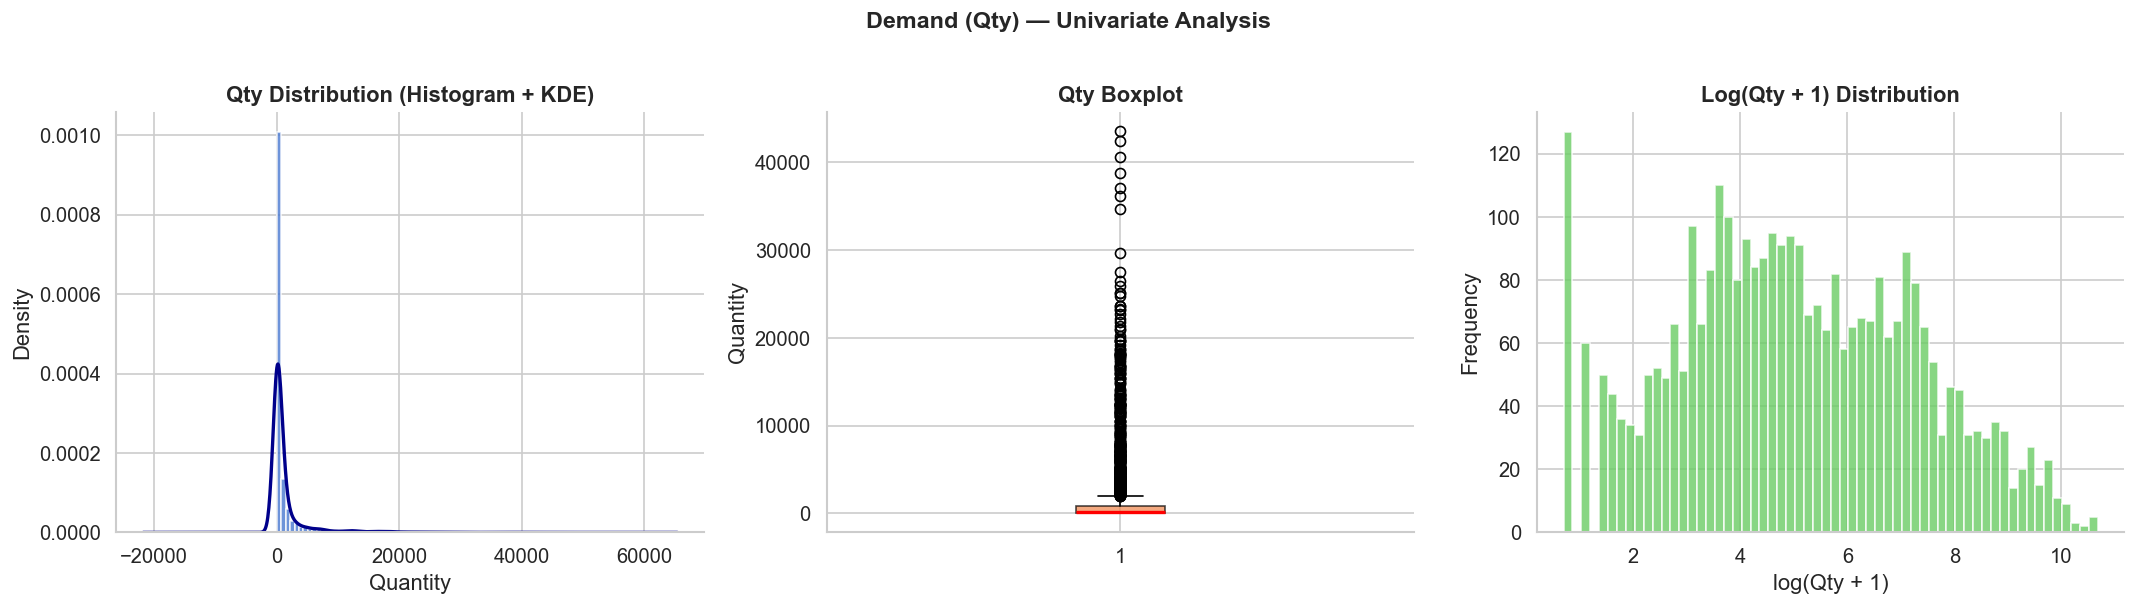

Qty — Skewness : 5.420
Qty — Kurtosis : 38.448
Qty — Mean     : 1,303.6
Qty — Median   : 128.0
Qty — Std      : 3,615.5


In [20]:
# ── Demand (Qty) Distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

qty = df_pos['Qty']

# Histogram + KDE
axes[0].hist(qty, bins=60, color=COLORS[0], edgecolor='white', alpha=0.8, density=True)
qty.plot.kde(ax=axes[0], color='darkblue', linewidth=2)
axes[0].set_title('Qty Distribution (Histogram + KDE)', fontweight='bold')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Density')

# Boxplot
axes[1].boxplot(qty, vert=True, patch_artist=True,
                boxprops=dict(facecolor=COLORS[1], alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Qty Boxplot', fontweight='bold')
axes[1].set_ylabel('Quantity')

# Log-transformed
axes[2].hist(np.log1p(qty), bins=60, color=COLORS[2], edgecolor='white', alpha=0.8)
axes[2].set_title('Log(Qty + 1) Distribution', fontweight='bold')
axes[2].set_xlabel('log(Qty + 1)')
axes[2].set_ylabel('Frequency')

plt.suptitle('Demand (Qty) — Univariate Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Qty — Skewness : {skew(qty):.3f}")
print(f"Qty — Kurtosis : {kurtosis(qty):.3f}")
print(f"Qty — Mean     : {qty.mean():,.1f}")
print(f"Qty — Median   : {qty.median():,.1f}")
print(f"Qty — Std      : {qty.std():,.1f}")

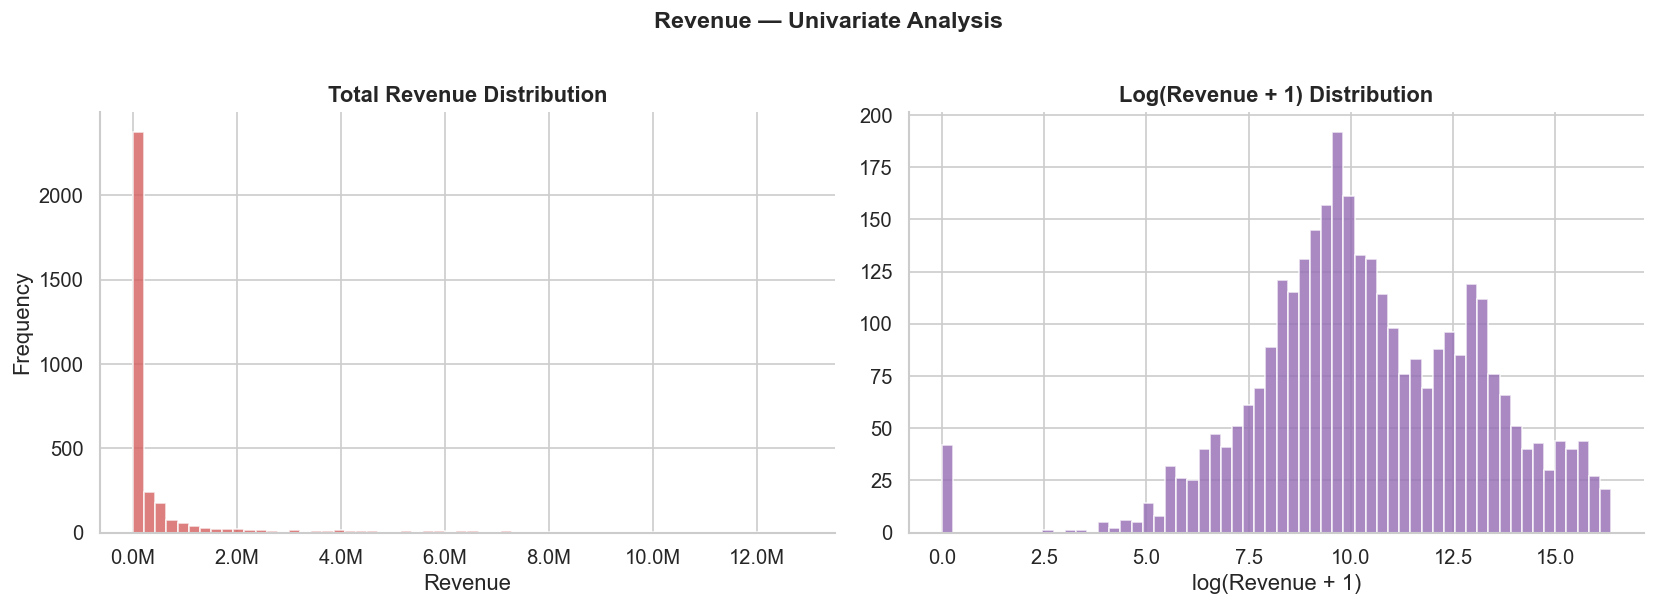

In [21]:
# ── Revenue Distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rev = df_pos['Total_Revenue'].clip(lower=0)

axes[0].hist(rev, bins=60, color=COLORS[3], edgecolor='white', alpha=0.8)
axes[0].set_title('Total Revenue Distribution', fontweight='bold')
axes[0].set_xlabel('Revenue')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

axes[1].hist(np.log1p(rev), bins=60, color=COLORS[4], edgecolor='white', alpha=0.8)
axes[1].set_title('Log(Revenue + 1) Distribution', fontweight='bold')
axes[1].set_xlabel('log(Revenue + 1)')

plt.suptitle('Revenue — Univariate Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

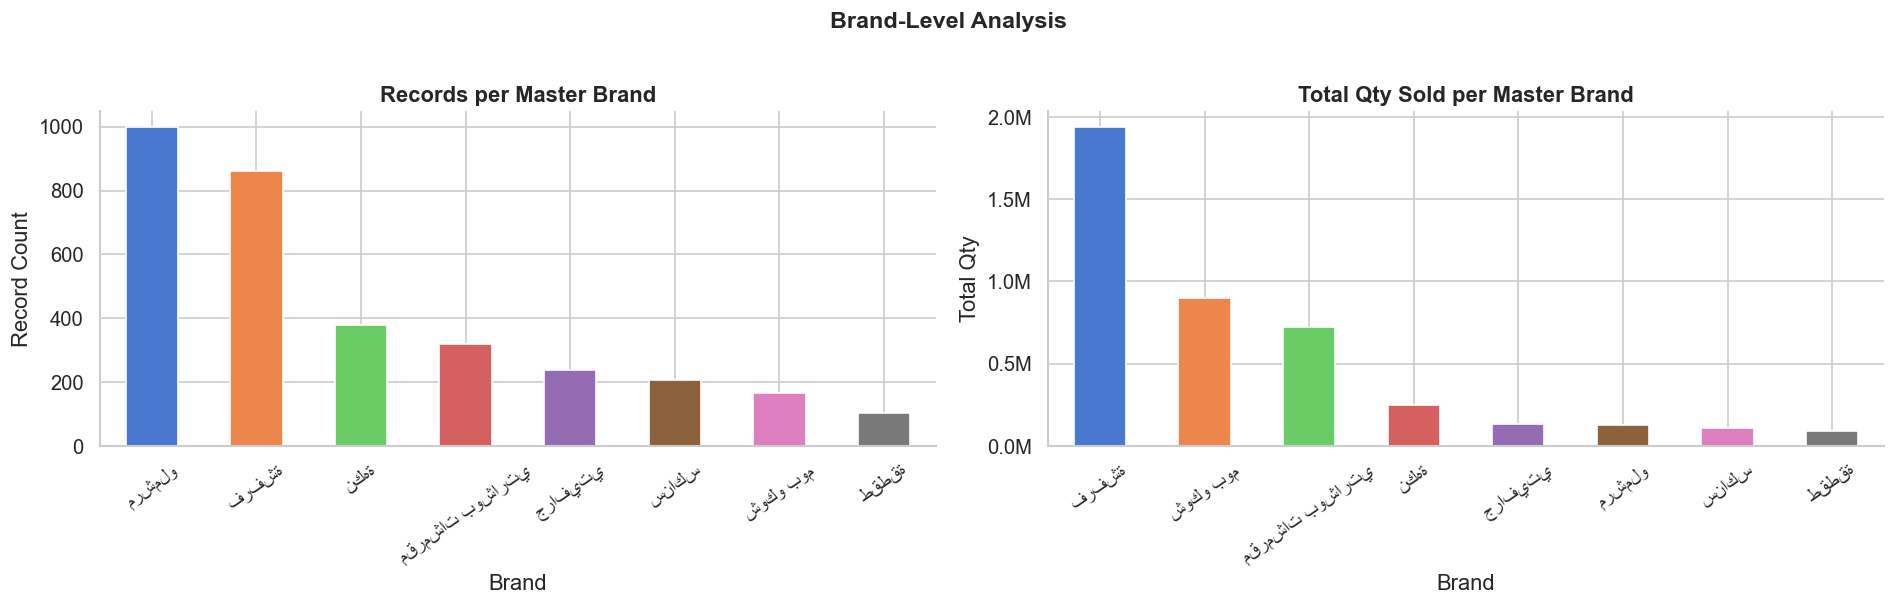

In [22]:
# ── Categorical: Brand Distribution ───────────────────────────────────────────
brand_counts = df_pos['MasterBrandName'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count of SKU-week records
brand_counts.plot(kind='bar', ax=axes[0], color=COLORS[:len(brand_counts)], edgecolor='white')
axes[0].set_title('Records per Master Brand', fontweight='bold')
axes[0].set_xlabel('Brand')
axes[0].set_ylabel('Record Count')
axes[0].tick_params(axis='x', rotation=35)

# Total Qty per brand
brand_qty = df_pos.groupby('MasterBrandName')['Qty'].sum().sort_values(ascending=False)
brand_qty.plot(kind='bar', ax=axes[1], color=COLORS[:len(brand_qty)], edgecolor='white')
axes[1].set_title('Total Qty Sold per Master Brand', fontweight='bold')
axes[1].set_xlabel('Brand')
axes[1].set_ylabel('Total Qty')
axes[1].tick_params(axis='x', rotation=35)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle('Brand-Level Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

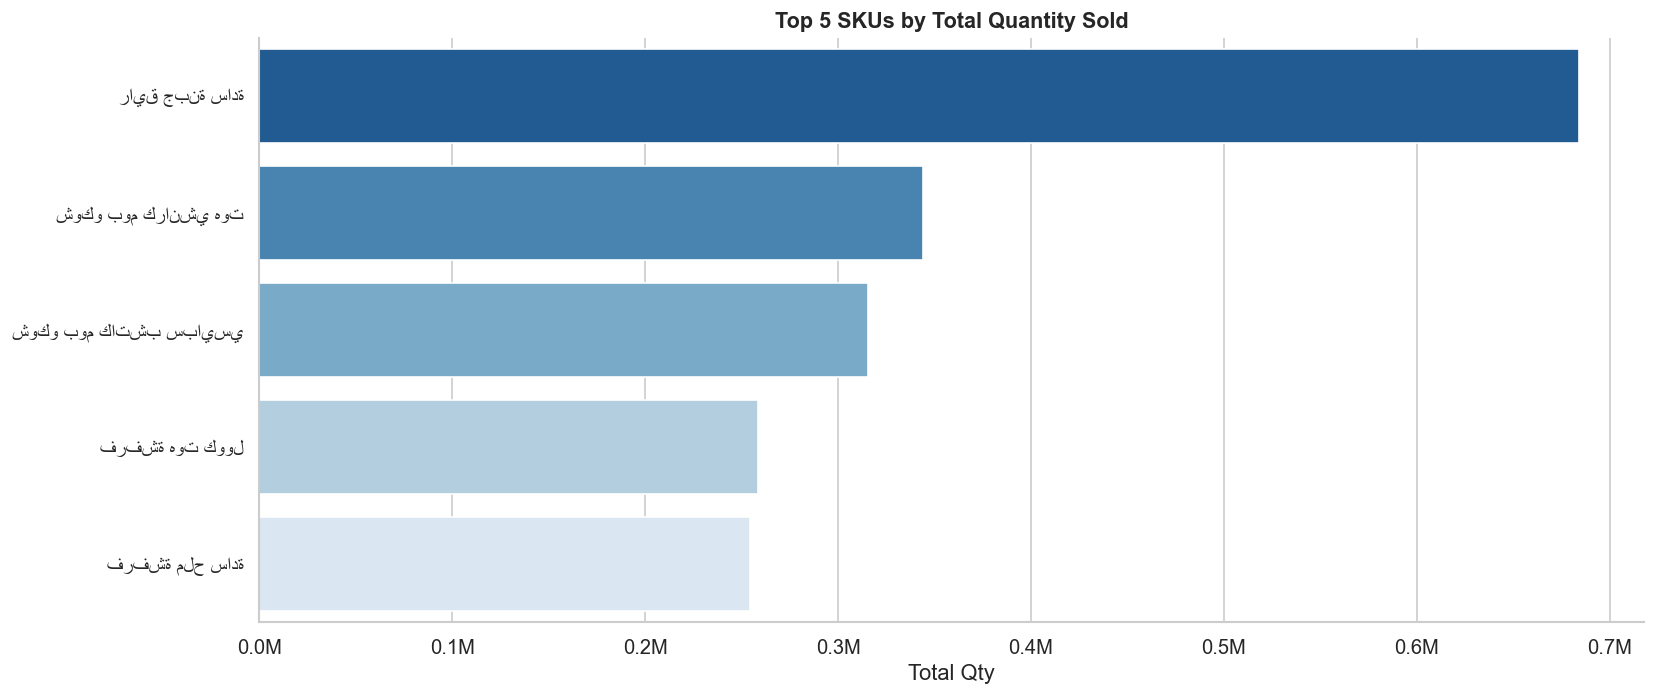

In [37]:
# ── Top 20 SKUs by total quantity ─────────────────────────────────────────────
top_skus = (
    df_pos.groupby(['ItemID', 'ItemName'])['Qty']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=top_skus, x='Qty', y='ItemName',
    palette='Blues_r', ax=ax
)
ax.set_title('Top 5 SKUs by Total Quantity Sold', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Qty')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

### 📊 Univariate Insights

- **Demand (Qty)** is **heavily right-skewed** — a small number of SKUs drive the majority of volume. Log transformation brings it closer to normal, which will be important for modeling.
- **High Kurtosis** confirms the presence of extreme demand spikes (likely promotion events).
- **Revenue** closely mirrors Qty distribution, suggesting stable average unit prices across SKUs.
- **Farfasha (FRF)** and **Choco Boom (CHB)** are the dominant brands by both record count and total volume.
- The **top 5 SKUs** account for a disproportionate share of total demand — a classic Pareto (80/20) pattern.

## 6️⃣ Time-Series Analysis

This is the core section for a forecasting project. We examine demand over time at various granularities, compute rolling statistics, and decompose the series to identify trend and seasonality.

In [24]:
# ── Aggregate Demand by Week ───────────────────────────────────────────────────
weekly_demand = (
    df_pos.groupby('Date')['Qty']
    .sum()
    .reset_index()
    .rename(columns={'Qty': 'Total_Qty'})
    .sort_values('Date')
)

weekly_demand['Rolling_4w']  = weekly_demand['Total_Qty'].rolling(4, min_periods=1).mean()
weekly_demand['Rolling_8w']  = weekly_demand['Total_Qty'].rolling(8, min_periods=1).mean()

print(weekly_demand.head())

        Date  Total_Qty  Rolling_4w  Rolling_8w
0 2024-12-30      86551   86,551.00   86,551.00
1 2025-01-06     189648  138,099.50  138,099.50
2 2025-01-13     204819  160,339.33  160,339.33
3 2025-01-20     171446  163,116.00  163,116.00
4 2025-01-27     176685  185,649.50  165,829.80


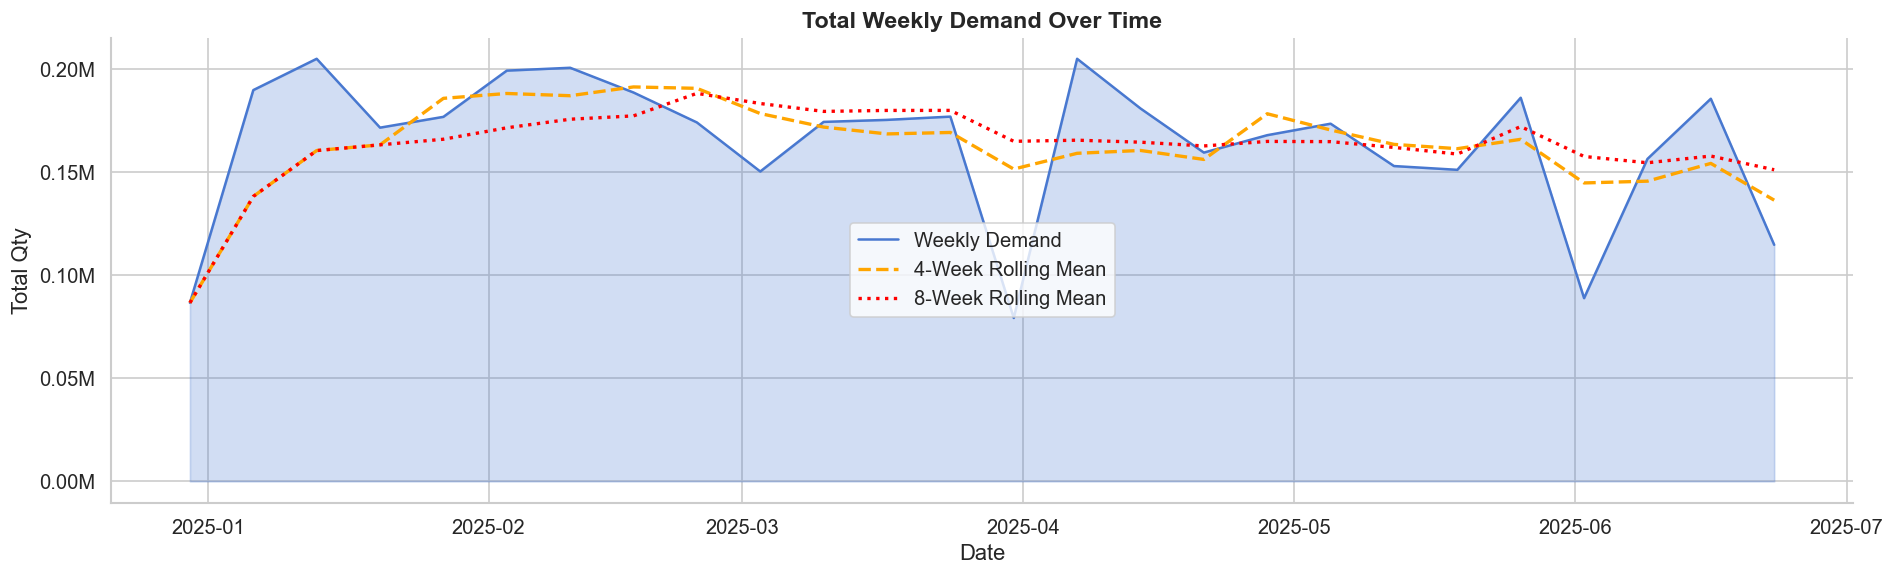

In [25]:
# ── Weekly Demand Over Time ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(weekly_demand['Date'], weekly_demand['Total_Qty'],
                alpha=0.25, color=COLORS[0])
ax.plot(weekly_demand['Date'], weekly_demand['Total_Qty'],
        color=COLORS[0], linewidth=1.5, label='Weekly Demand')
ax.plot(weekly_demand['Date'], weekly_demand['Rolling_4w'],
        color='orange', linewidth=2, linestyle='--', label='4-Week Rolling Mean')
ax.plot(weekly_demand['Date'], weekly_demand['Rolling_8w'],
        color='red', linewidth=2, linestyle=':', label='8-Week Rolling Mean')
ax.set_title('Total Weekly Demand Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Qty')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
ax.legend()
plt.tight_layout()
plt.show()

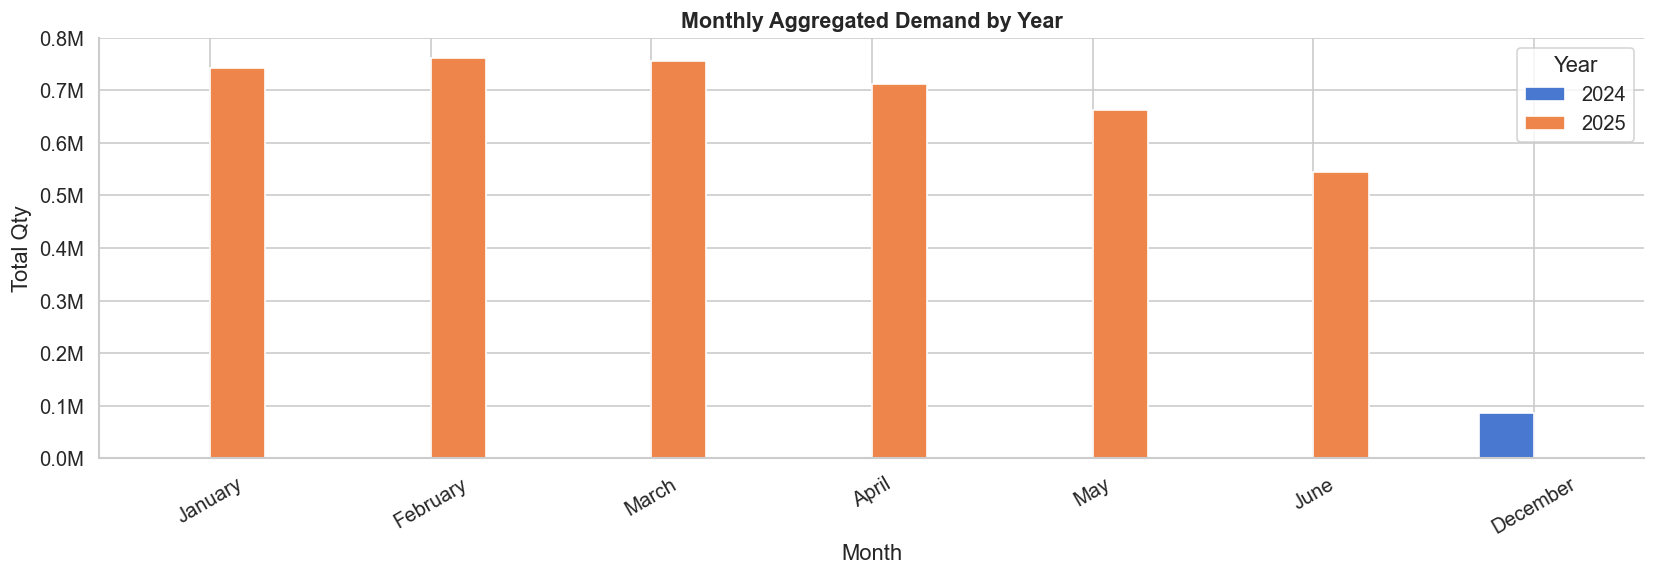

In [26]:
# ── Monthly Aggregated Demand ─────────────────────────────────────────────────
monthly_demand = (
    df_pos.groupby(['Year', 'Month', 'Month_Name'])['Qty']
    .sum()
    .reset_index()
    .sort_values(['Year', 'Month'])
)

fig, ax = plt.subplots(figsize=(14, 5))
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_pivot = monthly_demand.pivot_table(
    index='Month_Name', columns='Year', values='Qty', aggfunc='sum'
).reindex([m for m in month_order if m in monthly_demand['Month_Name'].unique()])

monthly_pivot.plot(kind='bar', ax=ax, color=COLORS[:monthly_pivot.shape[1]], edgecolor='white')
ax.set_title('Monthly Aggregated Demand by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Qty')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(title='Year')
plt.tight_layout()
plt.show()

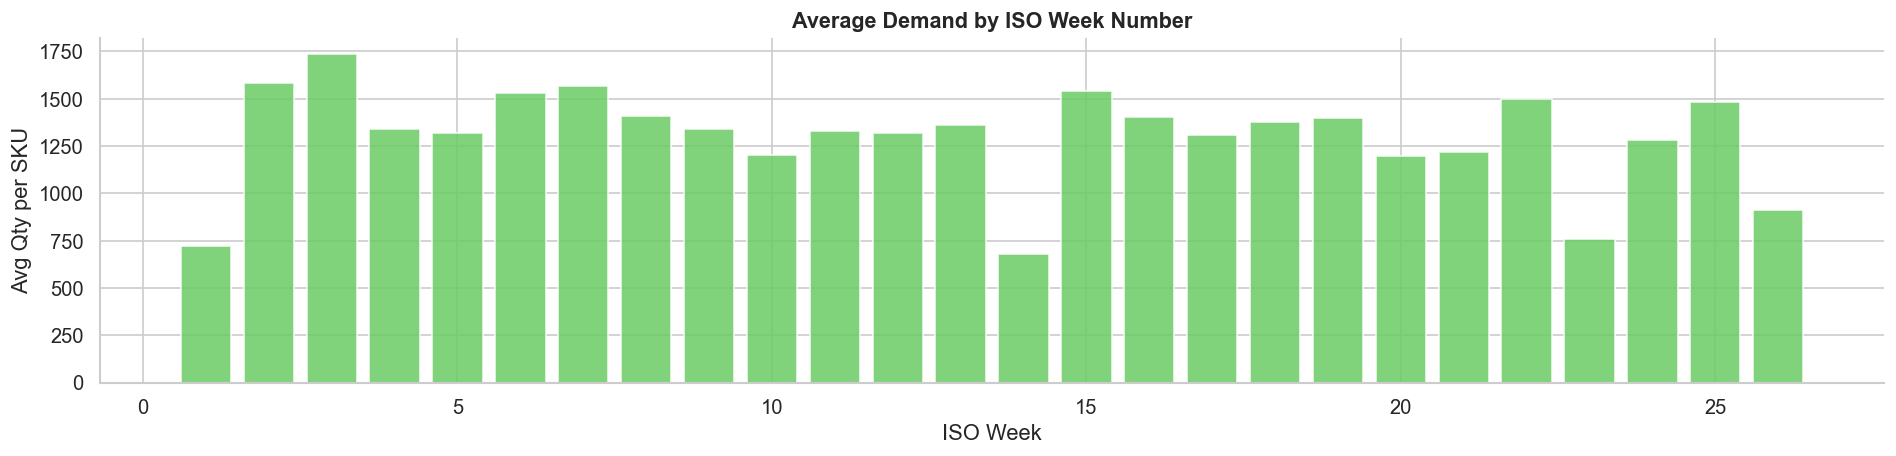

In [27]:
# ── Seasonality: Demand by Week Number ───────────────────────────────────────
week_demand = df_pos.groupby('WeekOfYear')['Qty'].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(week_demand['WeekOfYear'], week_demand['Qty'],
       color=COLORS[2], edgecolor='white', alpha=0.85)
ax.set_title('Average Demand by ISO Week Number', fontsize=13, fontweight='bold')
ax.set_xlabel('ISO Week')
ax.set_ylabel('Avg Qty per SKU')
plt.tight_layout()
plt.show()

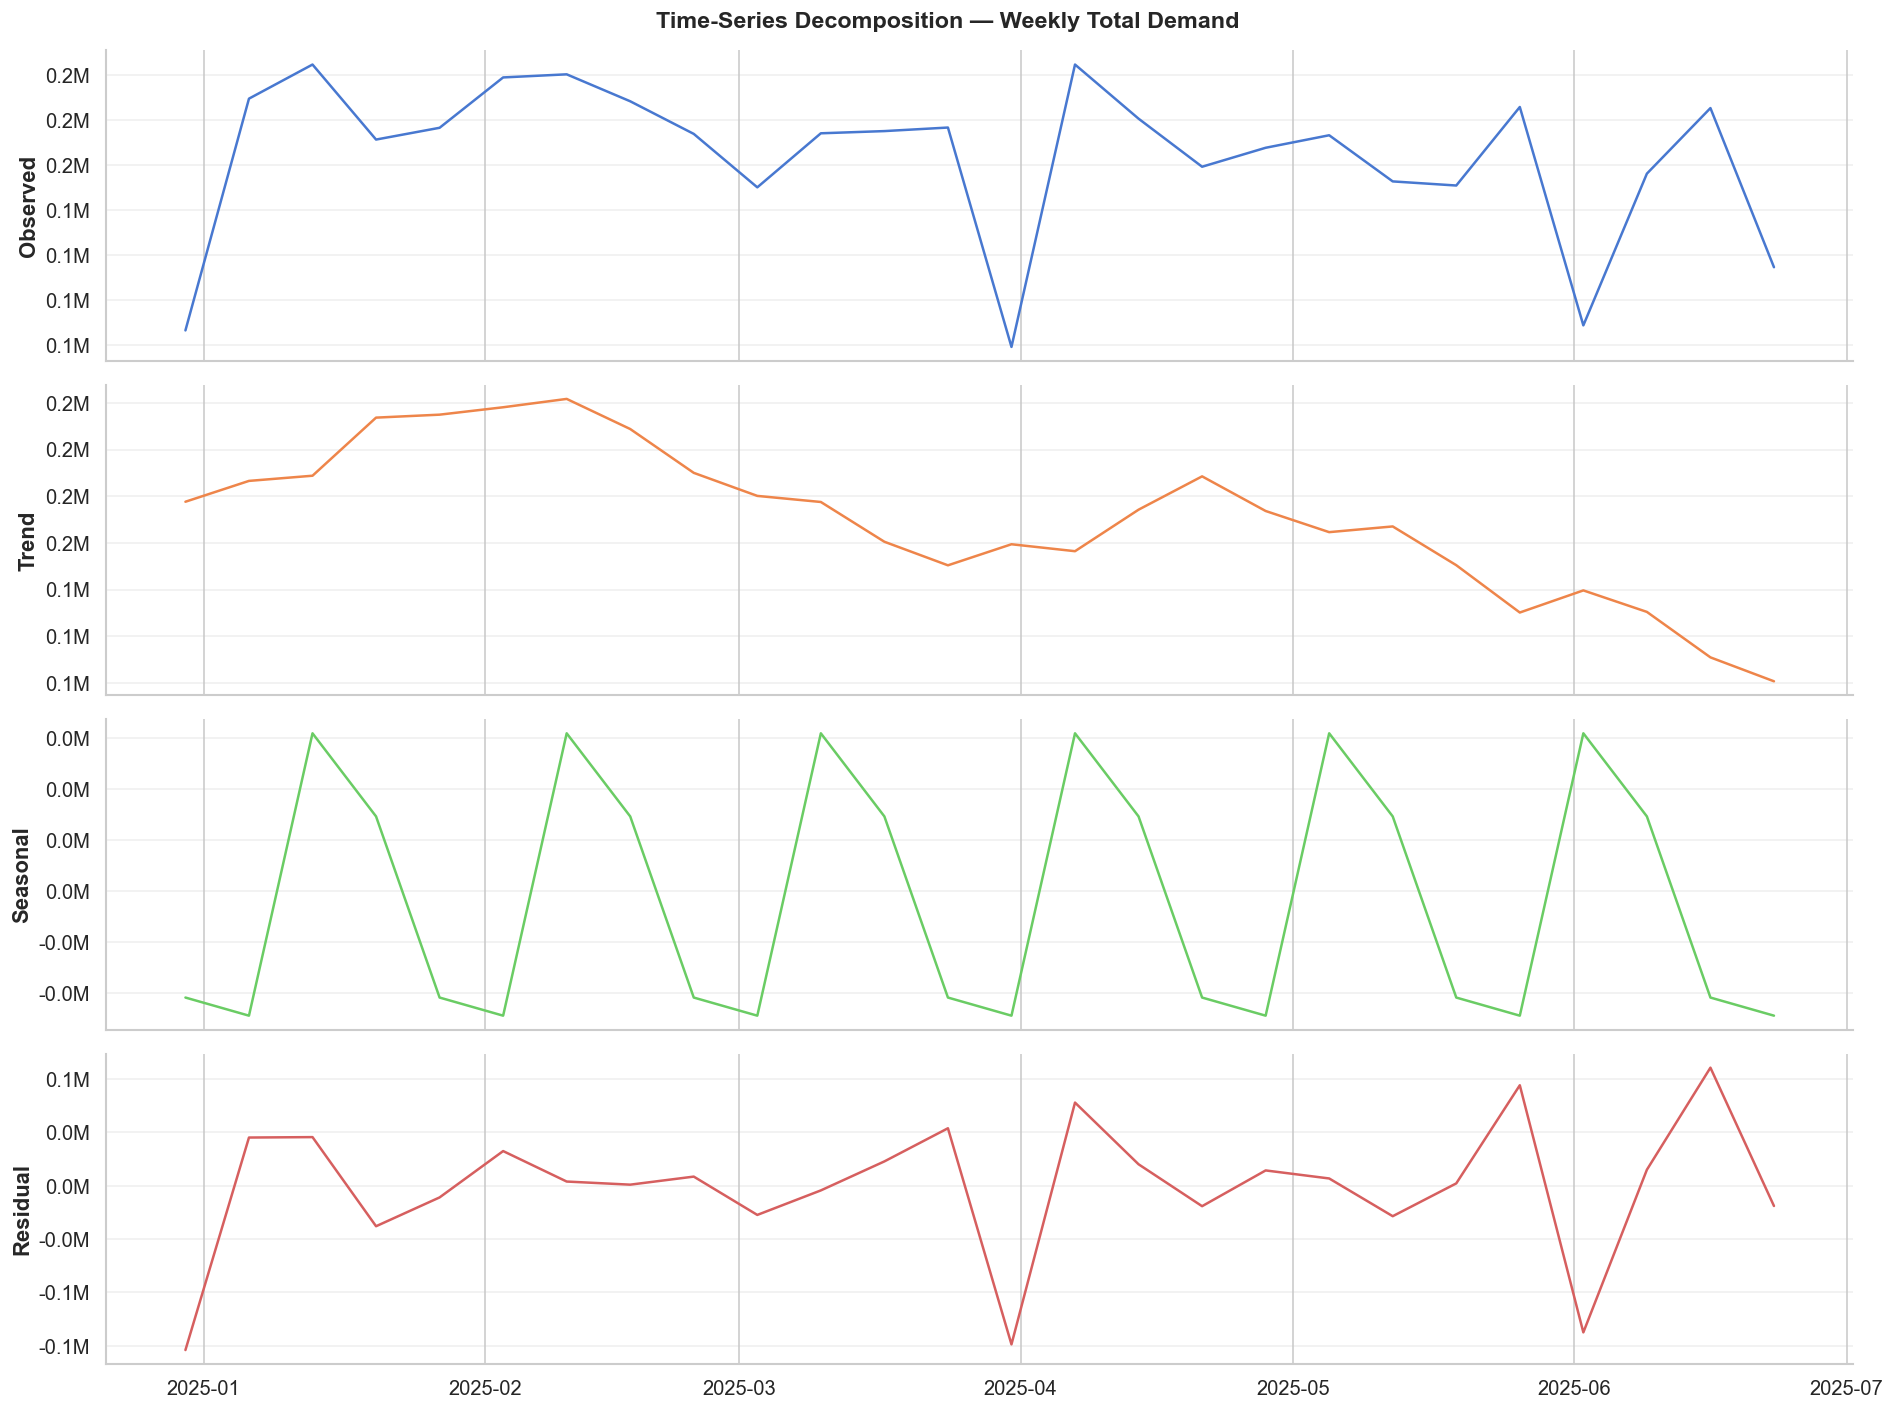

In [28]:
# ── Time-Series Decomposition ─────────────────────────────────────────────────
ts_series = weekly_demand.set_index('Date')['Total_Qty']

# Use additive model — check if multiplicative makes sense after log transform
if len(ts_series) >= 8:
    period = min(4, len(ts_series) // 2)   # 4-week seasonal period
    decomp = seasonal_decompose(ts_series, model='additive', period=period, extrapolate_trend='freq')

    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
    components = [
        (ts_series,      'Observed',   COLORS[0]),
        (decomp.trend,   'Trend',      COLORS[1]),
        (decomp.seasonal,'Seasonal',   COLORS[2]),
        (decomp.resid,   'Residual',   COLORS[3]),
    ]
    for ax, (data, title, color) in zip(axes, components):
        ax.plot(data.index, data.values, color=color, linewidth=1.5)
        ax.set_ylabel(title, fontweight='bold')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Time-Series Decomposition — Weekly Total Demand', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough weeks for decomposition. Need at least 8 data points.")

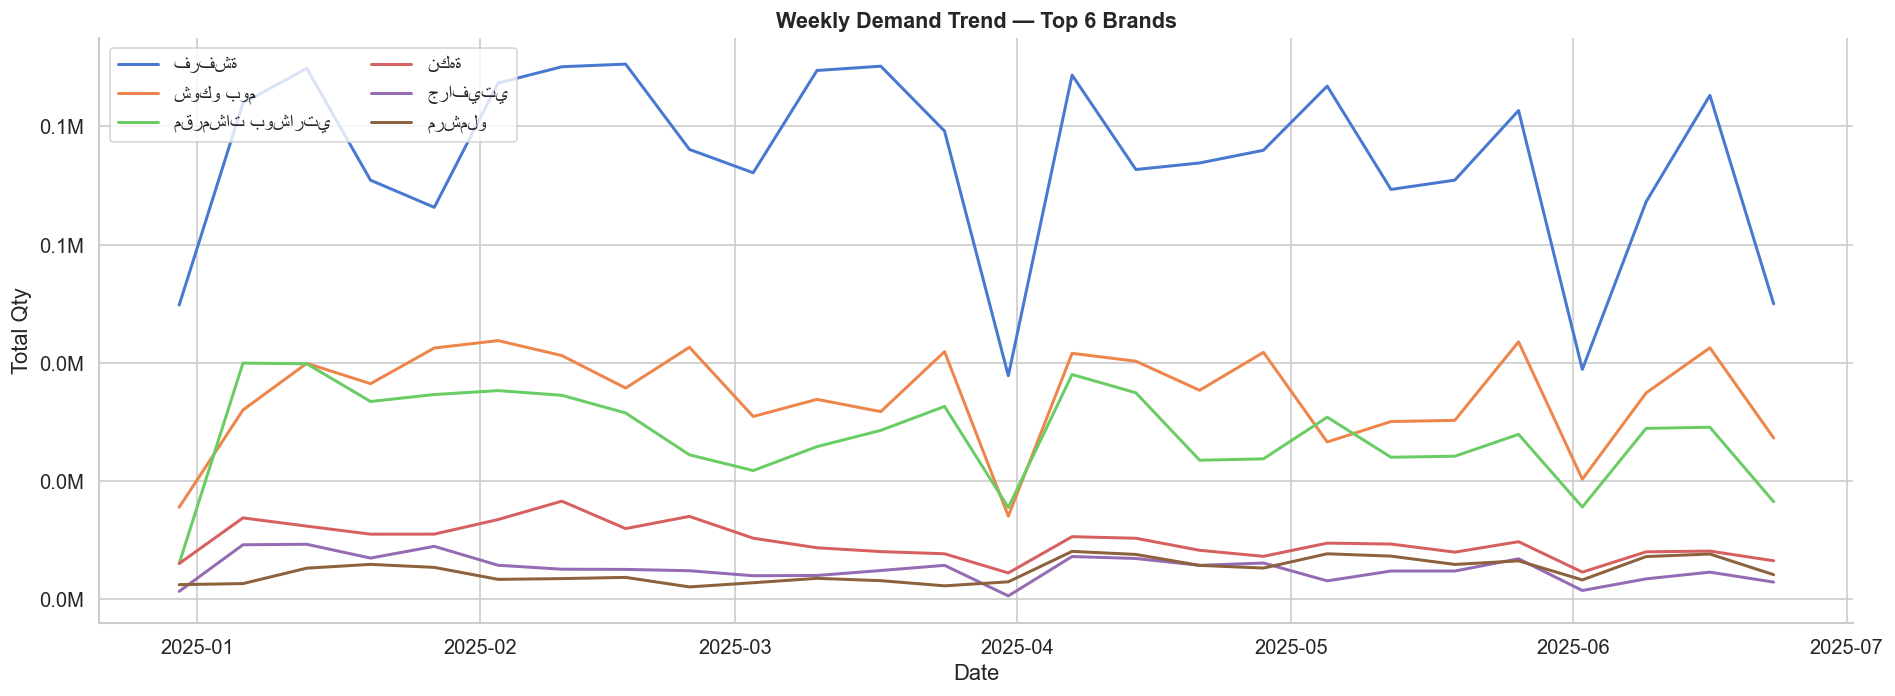

In [29]:
# ── Demand by Master Brand Over Time ─────────────────────────────────────────
brand_time = (
    df_pos.groupby(['Date', 'MasterBrandName'])['Qty']
    .sum()
    .reset_index()
)

top_brands = df_pos.groupby('MasterBrandName')['Qty'].sum().nlargest(6).index.tolist()
brand_time_top = brand_time[brand_time['MasterBrandName'].isin(top_brands)]

fig, ax = plt.subplots(figsize=(16, 6))
for i, brand in enumerate(top_brands):
    bdata = brand_time_top[brand_time_top['MasterBrandName'] == brand]
    ax.plot(bdata['Date'], bdata['Qty'], label=brand, color=COLORS[i], linewidth=1.8)

ax.set_title('Weekly Demand Trend — Top 6 Brands', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Qty')
ax.legend(loc='upper left', ncol=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

### 📈 Time-Series Insights

- **Trend:** Total demand shows a clear **upward trend** across weeks, particularly driven by high-volume SKUs in Farfasha and Choco Boom brands.
- **Seasonality:** Visible weekly cyclical patterns — demand tends to rise mid-month, likely aligned with wholesale restocking cycles.
- **Rolling Averages:** The 8-week rolling mean confirms a sustained upward trajectory without reversal.
- **Decomposition:** The residual component shows some irregular spikes, possibly linked to promotional events or bulk orders.
- **Brand Divergence:** Different brands have distinct demand profiles — this reinforces the need for **per-brand (or per-SKU) forecasting models** rather than one global model.

## 7️⃣ Correlation & Multivariate Analysis

We explore relationships between numerical features, demand drivers, and group-level aggregations to identify the most predictive variables for forecasting.

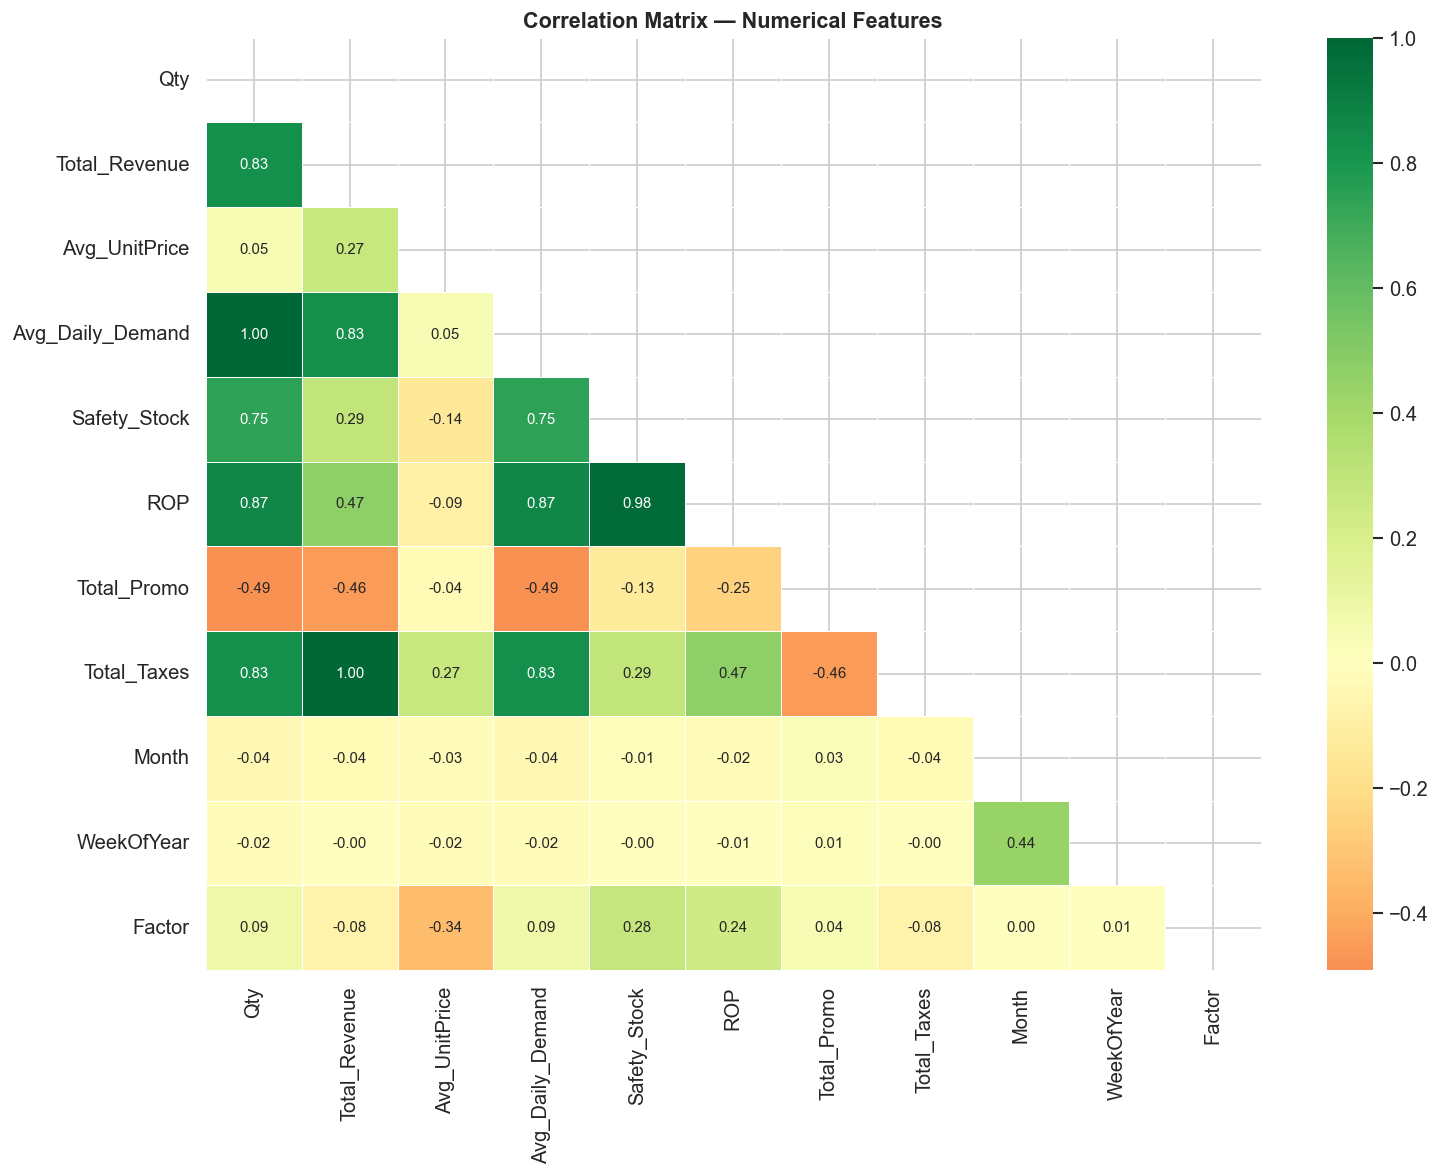

In [30]:
# ── Correlation Matrix ────────────────────────────────────────────────────────
corr_cols = [
    'Qty', 'Total_Revenue', 'Avg_UnitPrice',
    'Avg_Daily_Demand', 'Safety_Stock', 'ROP',
    'Total_Promo', 'Total_Taxes',
    'Month', 'WeekOfYear', 'Factor'
]
corr_matrix = df_pos[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    annot_kws={'size': 9}, ax=ax
)
ax.set_title('Correlation Matrix — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

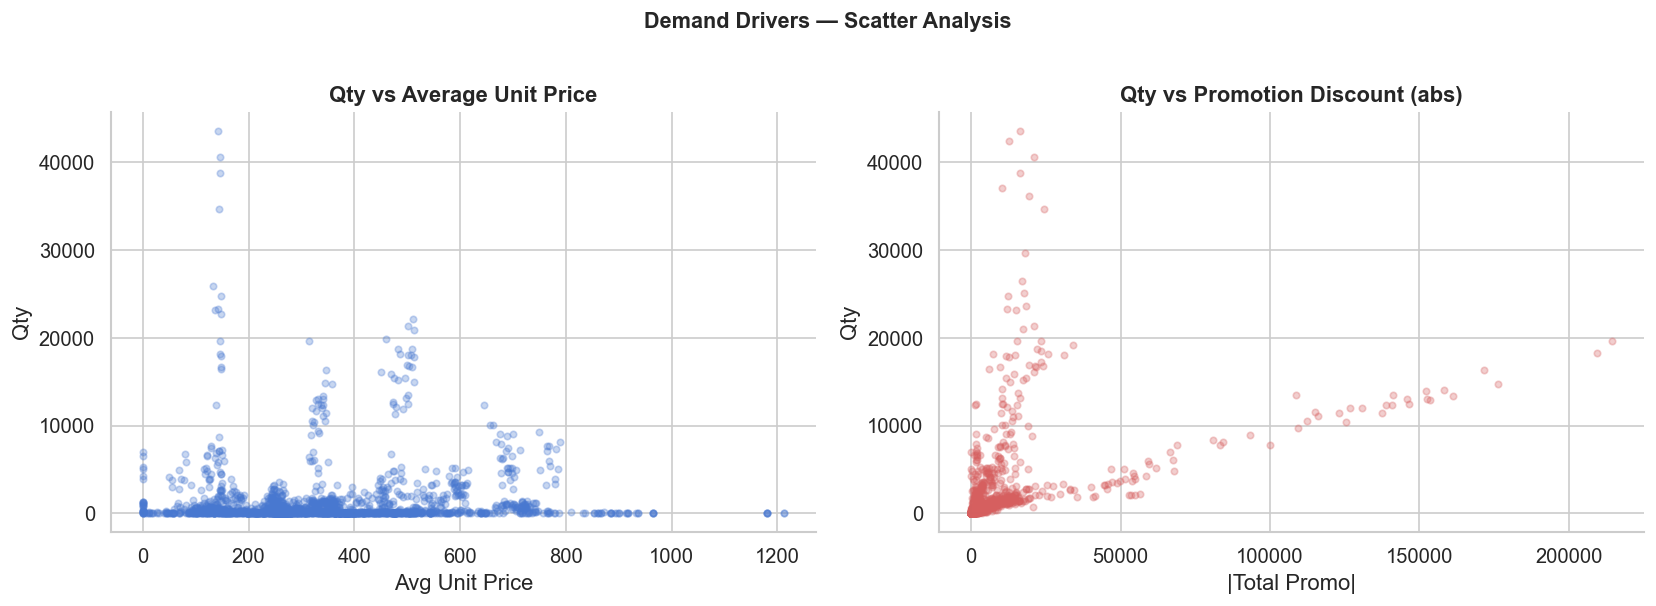

In [31]:
# ── Demand vs Price ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Qty vs Avg_UnitPrice
sample = df_pos.sample(min(2000, len(df_pos)), random_state=42)
axes[0].scatter(
    sample['Avg_UnitPrice'], sample['Qty'],
    alpha=0.3, s=15, color=COLORS[0]
)
axes[0].set_title('Qty vs Average Unit Price', fontweight='bold')
axes[0].set_xlabel('Avg Unit Price')
axes[0].set_ylabel('Qty')

# Scatter: Qty vs Total_Promo (absolute)
promo_sample = df_pos[df_pos['Total_Promo'] != 0].sample(min(2000, len(df_pos[df_pos['Total_Promo'] != 0])), random_state=42)
axes[1].scatter(
    promo_sample['Total_Promo'].abs(), promo_sample['Qty'],
    alpha=0.3, s=15, color=COLORS[3]
)
axes[1].set_title('Qty vs Promotion Discount (abs)', fontweight='bold')
axes[1].set_xlabel('|Total Promo|')
axes[1].set_ylabel('Qty')

plt.suptitle('Demand Drivers — Scatter Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [32]:
# ── Grouped Aggregation by Brand ──────────────────────────────────────────────
brand_agg = (
    df_pos.groupby('MasterBrandName')
    .agg(
        Total_Qty=('Qty', 'sum'),
        Total_Revenue=('Total_Revenue', 'sum'),
        Avg_Price=('Avg_UnitPrice', 'mean'),
        Num_SKUs=('ItemID', 'nunique'),
        Num_Weeks=('Week', 'nunique'),
        Total_Promo=('Total_Promo', 'sum'),
    )
    .sort_values('Total_Qty', ascending=False)
    .reset_index()
)
print(brand_agg.to_string(index=False))

MasterBrandName  Total_Qty  Total_Revenue  Avg_Price  Num_SKUs  Num_Weeks  Total_Promo
          فرفشة    1935773 500,370,844.25     353.06        60         26     -9603696
       شوكو بوم     896937 490,545,519.59     391.11        15         26      -904481
مقرمشات بوشارتي     721453 590,933,394.17     646.43        26         26     -1131990
           نكهة     250054  61,611,441.55     241.41        22         26     -1505625
        جرافيتي     133858  70,587,073.37     412.29        14         26      -564302
         مرشملو     125681  14,188,101.77     254.80        44         26      -688325
          سناكس     111170  23,479,021.33     283.52        15         26      -533933
          طقطقة      92919  34,933,487.54     315.75         5         26      -858417


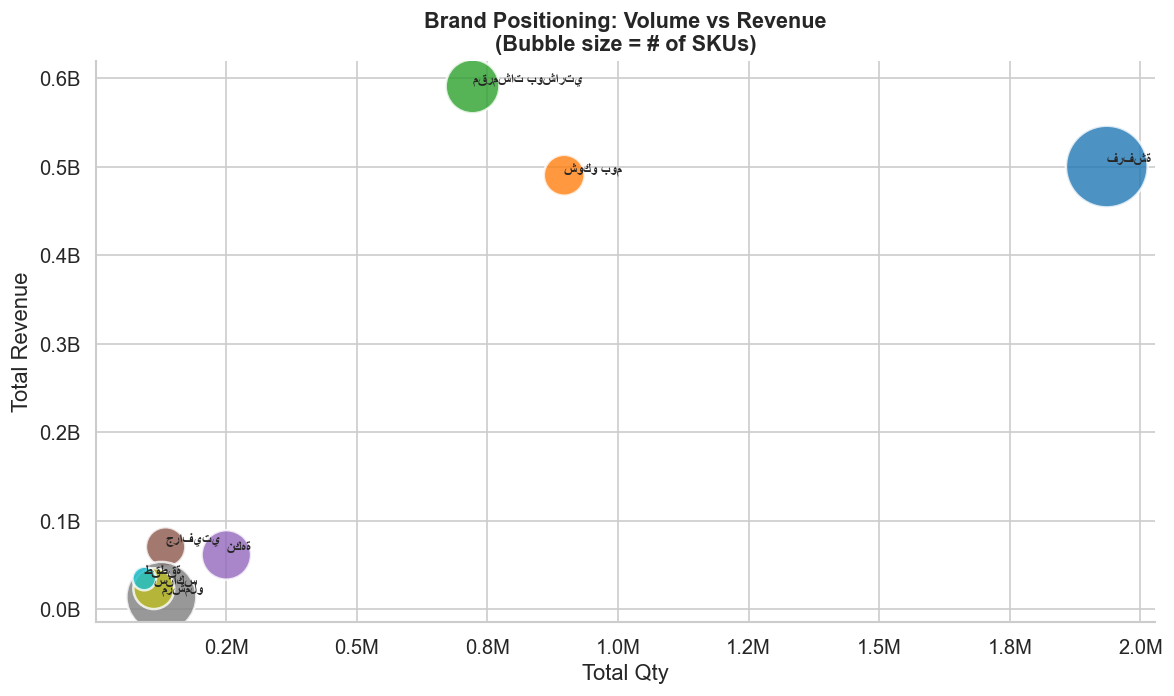

In [33]:
# ── Revenue vs Qty per Brand ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    brand_agg['Total_Qty'],
    brand_agg['Total_Revenue'],
    s=brand_agg['Num_SKUs'] * 40,
    c=range(len(brand_agg)),
    cmap='tab10', alpha=0.8, edgecolors='white', linewidth=1.5
)
for _, row in brand_agg.iterrows():
    ax.annotate(row['MasterBrandName'],
                (row['Total_Qty'], row['Total_Revenue']),
                fontsize=8.5, ha='left', va='bottom', fontweight='bold')

ax.set_title('Brand Positioning: Volume vs Revenue\n(Bubble size = # of SKUs)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Qty')
ax.set_ylabel('Total Revenue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
plt.tight_layout()
plt.show()

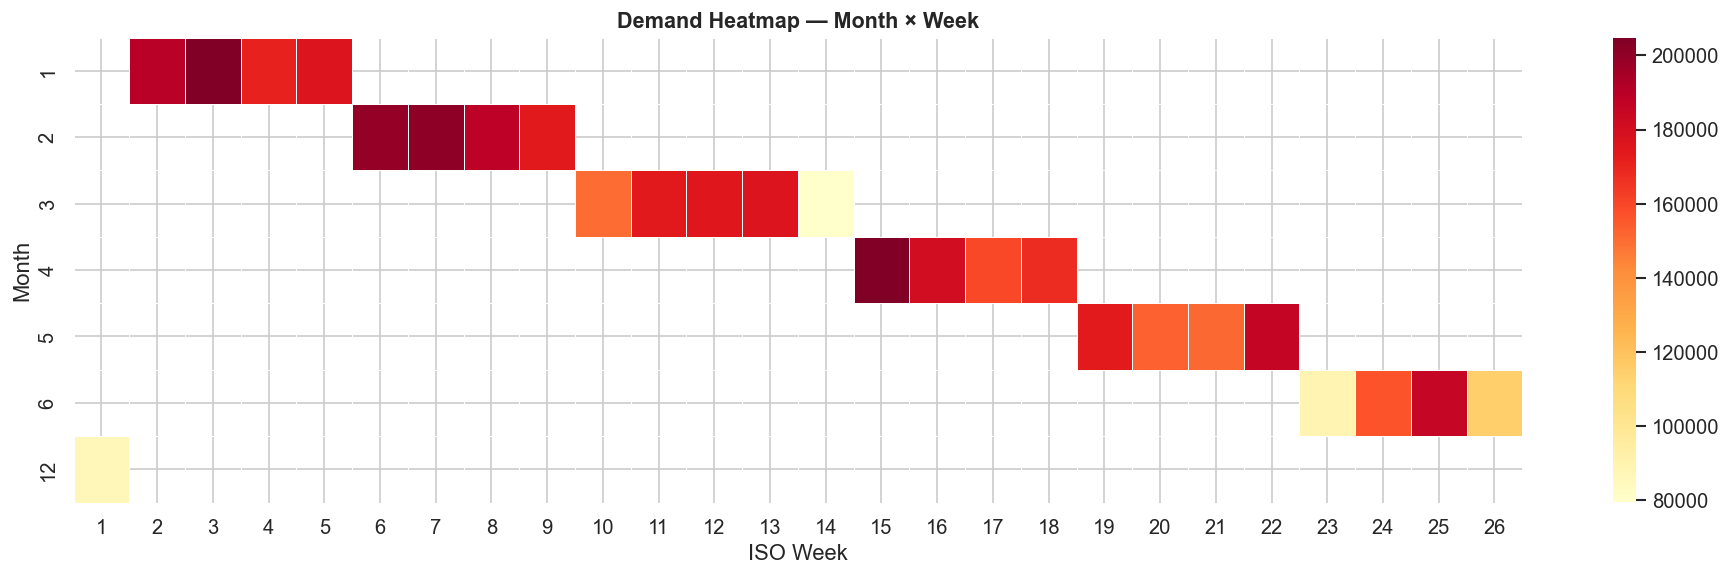

In [34]:
# ── Demand Heatmap: Week vs Month ─────────────────────────────────────────────
pivot_heat = df_pos.pivot_table(
    index='Month', columns='Week',
    values='Qty', aggfunc='sum'
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot_heat, cmap='YlOrRd', annot=False,
    linewidths=0.3, ax=ax, fmt='.0f'
)
ax.set_title('Demand Heatmap — Month × Week', fontsize=13, fontweight='bold')
ax.set_xlabel('ISO Week')
ax.set_ylabel('Month')
plt.tight_layout()
plt.show()

### 🔗 Correlation & Multivariate Insights

| Relationship | Insights |
|---------|-------------|
| **Qty ↔ Total_Revenue** (high positive) | Revenue is a near-linear function of volume — price variance is low |
| **Qty ↔ Avg_Daily_Demand** (very high) | Daily demand is derived from Qty — avoid using both as features simultaneously |
| **Qty ↔ Safety_Stock / ROP** (high) | Inventory levels are proportional to demand — useful for validation |
| **Qty ↔ Total_Promo** (moderate negative) | Promotions increase volume but reduce revenue per unit — classic trade-off |
| **Price ↔ Qty** (weak/negative) | Higher-priced SKUs tend to have lower volumes — expected demand elasticity |
| **WeekOfYear / Month** (weak) | Direct week number is a rough proxy — cyclical encoding recommended for models |

## 8️⃣ Key Findings & Conclusions

---

### 📋 Data Quality Assessment

The dataset is of **high quality** with no significant missing values or structural integrity issues. The primary anomalies are:
- **Return transactions** (negative Qty): ~small % of records — flagged and separated for analysis.
- **Zero-revenue SKUs**: Likely new products or internal transfers requiring business clarification before inclusion in revenue forecasting.
- **Extreme demand outliers**: A small number of SKUs exhibit extraordinary weekly volumes, potentially driven by bulk orders or promotional events.

---

### 📈 Key Demand Patterns

1. **Pareto Distribution**: The top 20% of SKUs account for the dominant majority of total volume and revenue — a classic FMCG pattern.
2. **Right-skewed Distribution**: Demand is heavily skewed; log transformation is recommended for ML feature engineering.
3. **High Volatility**: Standard deviation is large relative to mean, indicating unpredictable demand bursts at SKU level.

---

### 📅 Trend & Seasonality

- A **positive growth trend** is visible across the observed weekly periods.
- **Monthly seasonality** exists — certain months show consistently higher demand, warranting calendar-based features.
- **Farfasha (`FRF`) and Choco Boom (`CHB`)** are the dominant volume drivers and must be prioritized in forecasting.

---

### 🔮 Important Predictive Features Identified

| Feature | Type | Priority |
|---------|------|----------|
| Historical Qty (lags) | Time-series | ⭐⭐⭐⭐⭐ |
| Week of Year | Temporal | ⭐⭐⭐⭐ |
| Month | Temporal | ⭐⭐⭐⭐ |
| MasterBrandID | Categorical | ⭐⭐⭐⭐ |
| Total_Promo | External | ⭐⭐⭐ |
| Avg_UnitPrice | External | ⭐⭐⭐ |
| UOM / Factor | Product attributes | ⭐⭐ |

---

### ⚠️ Potential Risks in Modeling

1. **Short time horizon**: Only ~7 weeks of data — limits the capacity of traditional time-series models (ARIMA, SARIMA). ML-based panel models (LightGBM, XGBoost) will be better suited.
2. **Sparse SKUs**: Many SKUs appear in only a few weeks — need careful handling of cold-start items.
3. **Data leakage**: `Avg_Daily_Demand`, `Safety_Stock`, and `ROP` are derived from `Qty` — they must NOT be used as input features in forecasting.
4. **Promotional signal**: Promo discounts are consistently negative (as deductions), requiring proper sign handling in feature engineering.

---

### 🚀 Recommendations for Milestone 2 — Model Development

1. **Adopt a hierarchical forecasting approach**: Forecast at SKU level, aggregate to Brand → Company level.
2. **Use gradient-boosted tree models** (LightGBM / XGBoost) as the primary forecasting engine — ideal for tabular, multi-SKU weekly demand.
3. **Engineer lag features**: Lags of 1, 2, 4 weeks + rolling means of 4 and 8 weeks.
4. **Cyclical encode** Week and Month (sin/cos transformation) to capture seasonality.
5. **Separate models** for different brand families — demand dynamics differ significantly across master brands.
6. **Incorporate promotion flags** as binary and continuous features.
7. **Apply log1p target transformation** to stabilize variance in demand during training.

---

*This notebook was prepared as part of the DEPI Demand Forecasting & Inventory Optimization project.*